# Exercise 3: Helping with transcripts

Edit: **Lecture 1**   

        Lines: [382-391]
        
        Color: light blue :)

# Exercise 1: Visualizing the data over time

Extracting the data from the CSV file

In [101]:
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

"https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

In [102]:
#download(url, "covid_data.csv")

In [103]:
#using Pkg

In [104]:
#Pkg.add("CSV")

In [105]:
using CSV

In [106]:
data = CSV.read("covid_data.csv")  ;

Extracting the country names

In [107]:
all_countries = data[1:end, 2] ;

Looking for the names of the subset of countries using the following two lines

In [108]:
#one = [startswith(country, "F") for country in all_countries] 

In [109]:
#data[one, :] 

In [110]:
countries = ["China", "Japan", "Korea, South", "US", "United Kingdom", "Germany", "France"] ;

In [111]:
#size(data) -> (rows, columns)

In [112]:
num_days = size(data)[2] - 5 ;

In [113]:
country_dictionary = Dict(
    "China"=> zeros(num_days),
    "Japan"=> zeros(num_days),
    "Korea, South"=> zeros(num_days), 
    "US"=> zeros(num_days), 
    "United Kingdom"=> zeros(num_days), 
    "Germany"=> zeros(num_days), 
    "France" => zeros(num_days) 
) ;

In [114]:
unique_countries = unique(all_countries) ;

Going through all countries and summing up values corresponding to each country in our subset of countries

In [115]:
for country in unique_countries
    if country in countries
        list = country_dictionary[country]
        country_rows = collect(findall(all_countries .== country)[:, 1])
        for column in 1:num_days
            list[column] += sum(collect(data[country_rows[1]:country_rows[end], column+5])) 
        end
        country_dictionary[country] = list
    end
end

In [116]:
#country_dictionary

In [117]:
using Plots

In [118]:
p = plot();

In [119]:
using Dates
format = Dates.DateFormat("m/d/Y") ;
date_strings = String.(names(data))[6:end] ;
dates = parse.(Date, date_strings, format) .+ Year(2000) ;

In [120]:
for country in countries
    list = country_dictionary[country]
    for i in 1:num_days
        if list[i] == 0
        list[i] = NaN   
        end
    end
    country_dictionary[country] = list
end

Plotting all the countries on a single plot

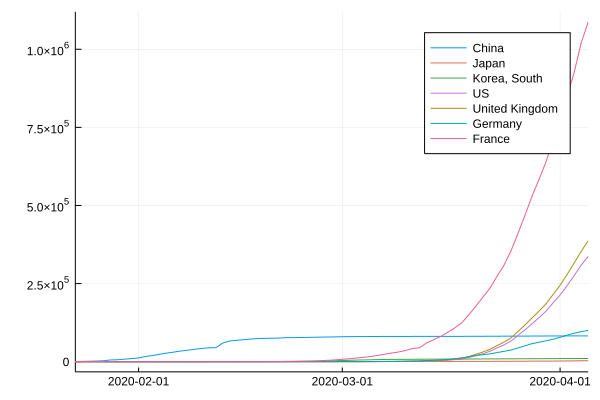

In [121]:
plot()
for country in countries
    plot!(dates, country_dictionary[country], label = country, xlim=map(Dates.value, (dates[1], dates[end])))
end
plot!()
# dates, xticks=dates[1:5:end], xrotation=45,

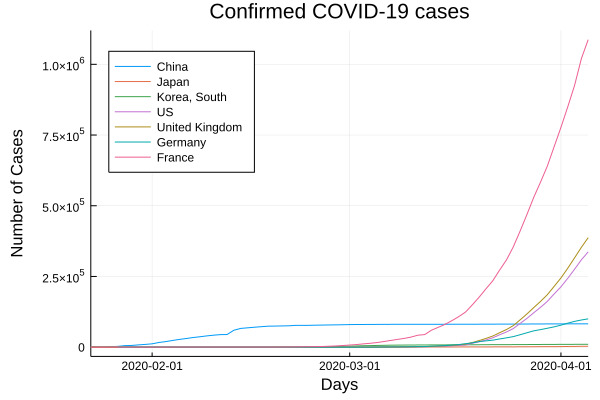

In [122]:
p
xlabel!("Days")
ylabel!("Number of Cases")
title!("Confirmed COVID-19 cases")
plot!(leg=:topleft, m=:0)

Plotting on a log scale

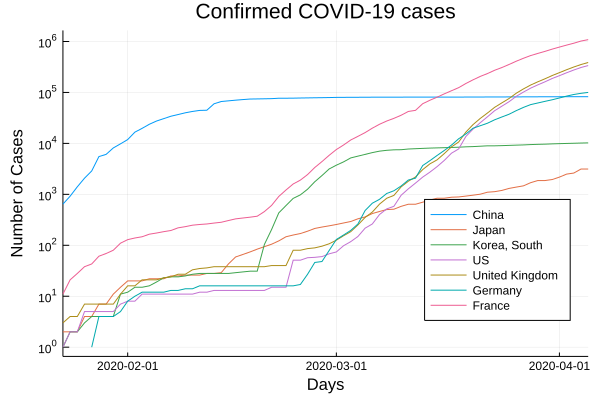

In [123]:
plot!(yscale=:log10, leg=:bottomright)

In [124]:
country_dictionary

Dict{String,Array{Float64,1}} with 7 entries:
  "Germany"        => [NaN, NaN, NaN, NaN, 1.0, 4.0, 4.0, 4.0, 5.0, 8.0  …  508…
  "United Kingdom" => [3.0, 4.0, 4.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 16.0  …  1…
  "China"          => [643.0, 920.0, 1406.0, 2075.0, 2877.0, 5509.0, 6087.0, 81…
  "Korea, South"   => [1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 4.0, 4.0, 11.0, 12.0  …  9…
  "Japan"          => [2.0, 2.0, 2.0, 4.0, 4.0, 7.0, 7.0, 11.0, 15.0, 20.0  …  …
  "France"         => [11.0, 21.0, 28.0, 38.0, 43.0, 61.0, 69.0, 80.0, 110.0, 1…
  "US"             => [1.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 7.0, 8.0  …  101…

Making the plot **interactive**

In [125]:
using Interact

In [126]:
#using Pkg

In [127]:
#Pkg.build("WebIO")

In [128]:
one()

MethodError: MethodError: no method matching one()
Closest candidates are:
  one(!Matched::Type{Missing}) at missing.jl:103
  one(!Matched::Type{Measures.Length{:mm,Float64}}) at /Users/dan/.julia/packages/Plots/cc8wh/src/layouts.jl:13
  one(!Matched::Type{Measures.Length{:pct,Float64}}) at /Users/dan/.julia/packages/Plots/cc8wh/src/layouts.jl:31
  ...

# Exercise 2: Visualizing changes

Creating a dictionary of total cases for all countries and our subset of countries

In [129]:
#total_cases_to_date => data set

In [130]:
list = zeros(num_days)
list[1] = sum(collect(data[:, 6]))
for i in 2:(num_days)
    list[i] = sum(collect(data[:, i+5])) 
    if list[i] == 0
        list[i] = NaN
    end
end
total_cases_to_date = merge(country_dictionary, Dict("All" => list)) ;

In [131]:
total_cases_to_date

Dict{String,Array{Float64,1}} with 8 entries:
  "Germany"        => [NaN, NaN, NaN, NaN, 1.0, 4.0, 4.0, 4.0, 5.0, 8.0  …  508…
  "United Kingdom" => [3.0, 4.0, 4.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 16.0  …  1…
  "China"          => [643.0, 920.0, 1406.0, 2075.0, 2877.0, 5509.0, 6087.0, 81…
  "All"            => [654.0, 941.0, 1434.0, 2118.0, 2927.0, 5578.0, 6166.0, 82…
  "Korea, South"   => [1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 4.0, 4.0, 11.0, 12.0  …  9…
  "Japan"          => [2.0, 2.0, 2.0, 4.0, 4.0, 7.0, 7.0, 11.0, 15.0, 20.0  …  …
  "France"         => [11.0, 21.0, 28.0, 38.0, 43.0, 61.0, 69.0, 80.0, 110.0, 1…
  "US"             => [1.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 7.0, 8.0  …  101…

Creating a dictionary of new cases

In [132]:
total_cases_to_date

Dict{String,Array{Float64,1}} with 8 entries:
  "Germany"        => [NaN, NaN, NaN, NaN, 1.0, 4.0, 4.0, 4.0, 5.0, 8.0  …  508…
  "United Kingdom" => [3.0, 4.0, 4.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 16.0  …  1…
  "China"          => [643.0, 920.0, 1406.0, 2075.0, 2877.0, 5509.0, 6087.0, 81…
  "All"            => [654.0, 941.0, 1434.0, 2118.0, 2927.0, 5578.0, 6166.0, 82…
  "Korea, South"   => [1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 4.0, 4.0, 11.0, 12.0  …  9…
  "Japan"          => [2.0, 2.0, 2.0, 4.0, 4.0, 7.0, 7.0, 11.0, 15.0, 20.0  …  …
  "France"         => [11.0, 21.0, 28.0, 38.0, 43.0, 61.0, 69.0, 80.0, 110.0, 1…
  "US"             => [1.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 7.0, 8.0  …  101…

In [133]:
y = Dict(
    "China"=> total_cases_to_date["China"],
    "Japan"=> total_cases_to_date["Japan"],
    "Korea, South"=> total_cases_to_date["Korea, South"], 
    "US"=> total_cases_to_date["US"], 
    "United Kingdom"=> total_cases_to_date["United Kingdom"], 
    "Germany"=> total_cases_to_date["Germany"], 
    "France" => total_cases_to_date["France"],
    "All" => total_cases_to_date["All"]
) ;

In [134]:
y

Dict{String,Array{Float64,1}} with 8 entries:
  "Germany"        => [NaN, NaN, NaN, NaN, 1.0, 4.0, 4.0, 4.0, 5.0, 8.0  …  508…
  "United Kingdom" => [3.0, 4.0, 4.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 16.0  …  1…
  "China"          => [643.0, 920.0, 1406.0, 2075.0, 2877.0, 5509.0, 6087.0, 81…
  "All"            => [654.0, 941.0, 1434.0, 2118.0, 2927.0, 5578.0, 6166.0, 82…
  "Korea, South"   => [1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 4.0, 4.0, 11.0, 12.0  …  9…
  "Japan"          => [2.0, 2.0, 2.0, 4.0, 4.0, 7.0, 7.0, 11.0, 15.0, 20.0  …  …
  "France"         => [11.0, 21.0, 28.0, 38.0, 43.0, 61.0, 69.0, 80.0, 110.0, 1…
  "US"             => [1.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 7.0, 8.0  …  101…

In [135]:
total_cases_to_date

Dict{String,Array{Float64,1}} with 8 entries:
  "Germany"        => [NaN, NaN, NaN, NaN, 1.0, 4.0, 4.0, 4.0, 5.0, 8.0  …  508…
  "United Kingdom" => [3.0, 4.0, 4.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 16.0  …  1…
  "China"          => [643.0, 920.0, 1406.0, 2075.0, 2877.0, 5509.0, 6087.0, 81…
  "All"            => [654.0, 941.0, 1434.0, 2118.0, 2927.0, 5578.0, 6166.0, 82…
  "Korea, South"   => [1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 4.0, 4.0, 11.0, 12.0  …  9…
  "Japan"          => [2.0, 2.0, 2.0, 4.0, 4.0, 7.0, 7.0, 11.0, 15.0, 20.0  …  …
  "France"         => [11.0, 21.0, 28.0, 38.0, 43.0, 61.0, 69.0, 80.0, 110.0, 1…
  "US"             => [1.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 7.0, 8.0  …  101…

In [142]:
a = [1,2,3]
b = a

b[2] = 404
@assert a == b

In [136]:
for countr in keys(y)
    yprim = deepcopy(y[countr])
    cases = deepcopy(total_cases_to_date[countr])
    for i in 7:num_days
        ( cases[i] == NaN ) && continue
        ( cases[i-6] == NaN ) && continue

        yprim[i] = cases[i]-cases[i-6]
        ( yprim[i] <= 0 ) && ( yprim[i] = NaN )
    end
    y[countr] = yprim
end

In [137]:
y

Dict{String,Array{Float64,1}} with 8 entries:
  "Germany"        => [NaN, NaN, NaN, NaN, 1.0, 4.0, NaN, NaN, NaN, NaN  …  286…
  "United Kingdom" => [3.0, 4.0, 4.0, 7.0, 7.0, 7.0, 4.0, 3.0, 7.0, 9.0  …  863…
  "China"          => [643.0, 920.0, 1406.0, 2075.0, 2877.0, 5509.0, 5444.0, 72…
  "All"            => [654.0, 941.0, 1434.0, 2118.0, 2927.0, 5578.0, 5512.0, 72…
  "Korea, South"   => [1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 3.0, 2.0, 9.0, 9.0  …  533…
  "Japan"          => [2.0, 2.0, 2.0, 4.0, 4.0, 7.0, 5.0, 9.0, 13.0, 16.0  …  4…
  "France"         => [11.0, 21.0, 28.0, 38.0, 43.0, 61.0, 58.0, 59.0, 82.0, 91…
  "US"             => [1.0, 2.0, 2.0, 5.0, 5.0, 5.0, 4.0, 3.0, 5.0, 3.0  …  761…

Plotting *total number of cases* vs. *number of new cases*

In [138]:
p_new = plot() ;

In [139]:
total_cases_to_date["Germany"] .- y["Germany"]

74-element Array{Float64,1}:
   NaN
   NaN
   NaN
   NaN
     0.0
     0.0
   NaN
   NaN
   NaN
   NaN
     1.0
     4.0
     4.0
     ⋮
 15320.0
 19848.0
 22213.0
 24873.0
 29056.0
 32986.0
 37323.0
 43938.0
 50871.0
 57695.0
 62095.0
 66885.0

In [140]:
plot()
for country in keys(y)
    plot!(p_new, total_cases_to_date[country], y[country], label = country, yscale=:log10, xscale=:log10)
end

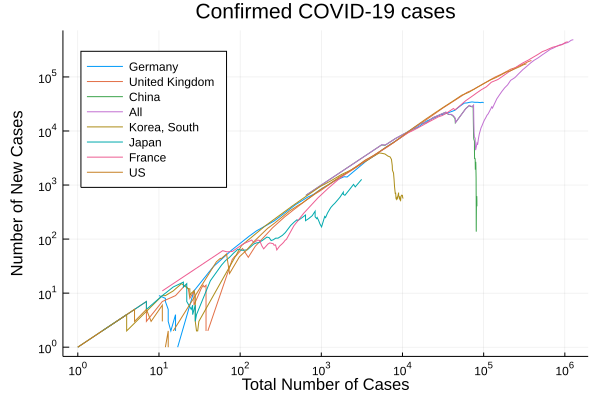

In [141]:
p_new
xlabel!("Total Number of Cases")
ylabel!("Number of New Cases")
title!("Confirmed COVID-19 cases")
plot!(leg=:topleft, m=:0)

#s = scatter(total_cases_to_date["China"], y["China"])
#annotate!(5*10^4, 5*10^4, text("China", 7, :black))

In [ ]:
#using Pkg

In [ ]:
#Pkg.rm("Interact")

In [ ]:
#Pkg.rm("WebIO")

In [ ]:
#Pkg.add("Interact")

In [ ]:
#Pkg.add("WebIO")

In [ ]:
#using Interact

In [ ]:
#WebIO.install_jupyter_nbextension()

In [ ]:
using Interact

In [ ]:
using WebIO

In [ ]:
#using Pkg; Pkg.add("Knockout")

In [ ]:
#@manipulate for i in 1:10
#    @show i
#end